In [87]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_data(file_path, y_columns, legend_names=None, title='Training Stats',
              x_column='epoch', xlabel='Epochs', ylabel=None, figsize=(10, 6),
              label_fontsize=20, legend_fontsize=18, tick_fontsize=18):
    data = pd.read_csv(file_path)

    if isinstance(y_columns, str):
        y_columns = [y_columns]

    missing_columns = [col for col in [x_column, *y_columns] if col not in data.columns]
    if missing_columns:
        raise ValueError(f'Missing column(s) in CSV: {missing_columns}')

    if legend_names is None:
        legend_names = y_columns
    elif isinstance(legend_names, str):
        legend_names = [legend_names]

    if len(legend_names) != len(y_columns):
        raise ValueError('legend_names must have the same length as y_columns')

    # Strip the trainS_/val_/etc. prefix so e.g. trainS_acc and val_acc share
    # the same metric key ("acc") and therefore the same color + marker.
    def metric_key(col):
        if col.startswith("trainS_"):
            return col[len("trainS_"):]
        if "_" in col:
            return col.split("_", 1)[1]
        return col

    metric_order = []
    for col in y_columns:
        m = metric_key(col)
        if m not in metric_order:
            metric_order.append(m)

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    marker_cycle = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', '<', '>']
    metric_color = {m: color_cycle[i % len(color_cycle)] for i, m in enumerate(metric_order)}
    metric_marker = {m: marker_cycle[i % len(marker_cycle)] for i, m in enumerate(metric_order)}

    fig, ax = plt.subplots(figsize=figsize)
    for column, label in zip(y_columns, legend_names):
        m = metric_key(column)
        color = metric_color[m]
        marker = metric_marker[m]
        if "trainS" in column:
            ax.plot(data[x_column], data[column], marker=marker, linestyle='--',
                    color=color, label=label, alpha=0.7)
        else:
            ax.plot(data[x_column], data[column], marker=marker, linestyle='-',
                    color=color, label=label)

    ax.set_title(title)
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    ax.set_ylabel(ylabel or ', '.join(y_columns), fontsize=label_fontsize)
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.grid(True)
    ax.legend(loc='lower left', fontsize=legend_fontsize)
    plt.show()

    return fig, ax

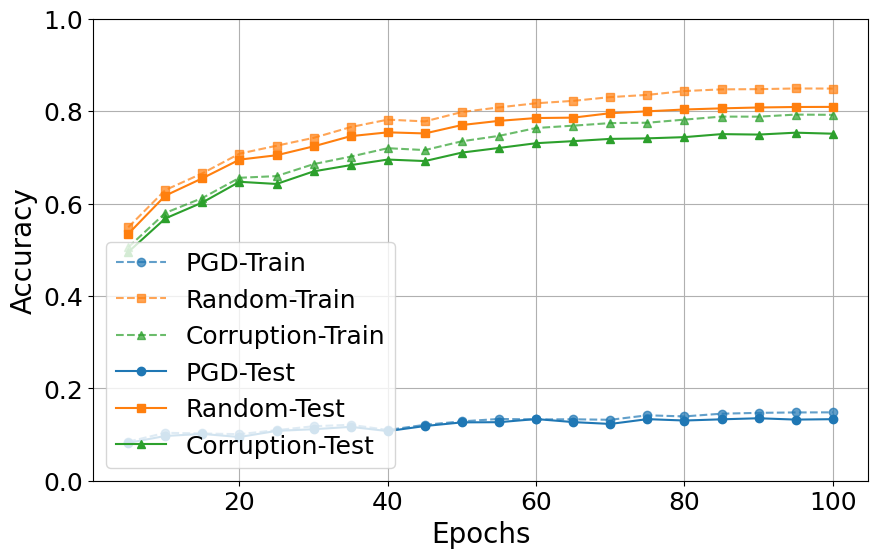

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Epochs', ylabel='Accuracy'>)

In [ ]:
plot_data(
    file_path="../../ckp/nppr_training/pr_training/cifar10/resnet18/loc_entropy/loc_ent_eps10_L100_G0.05_N1_Aug_training_info.csv",
    
    y_columns=["trainS_pgd", "trainS_random_l", "trainS_corr", \
         "val_pgd","val_random_l", "val_corr",],
    legend_names=["PGD-Train", "Random-Train", "Corruption-Train", "PGD-Test", "Random-Test", "Corruption-Test"],
    title="",
    ylabel="Accuracy"
)

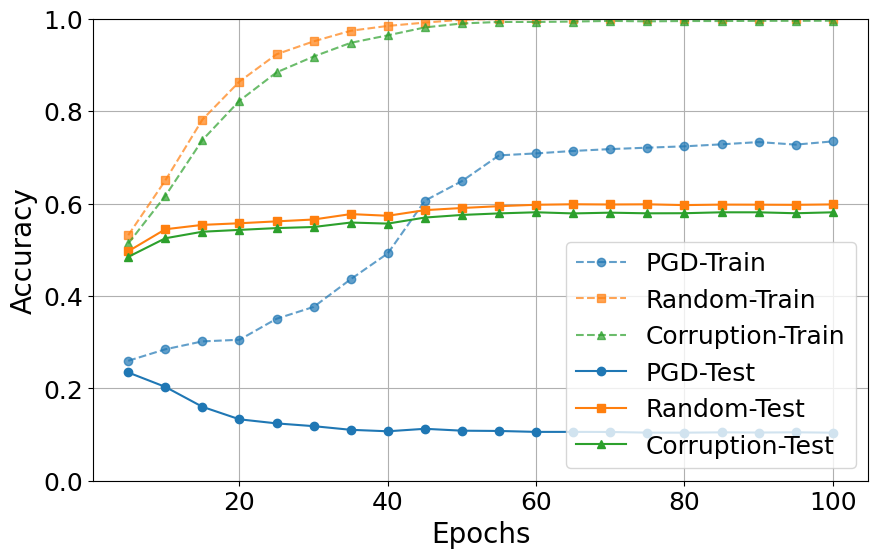

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Epochs', ylabel='Accuracy'>)

In [85]:
plot_data(
    file_path="../../ckp/nppr_training/adv_training/cifar10/resnet18/pgd3/resnet18_cifar10_adv_pgd_training_info.csv",
    
    y_columns=["trainS_pgd", "trainS_random_l", "trainS_corr", \
         "val_pgd","val_random_l", "val_corr",],
    legend_names=["PGD-Train", "Random-Train", "Corruption-Train", "PGD-Test", "Random-Test", "Corruption-Test"],
    title="",
    ylabel="Accuracy"
)

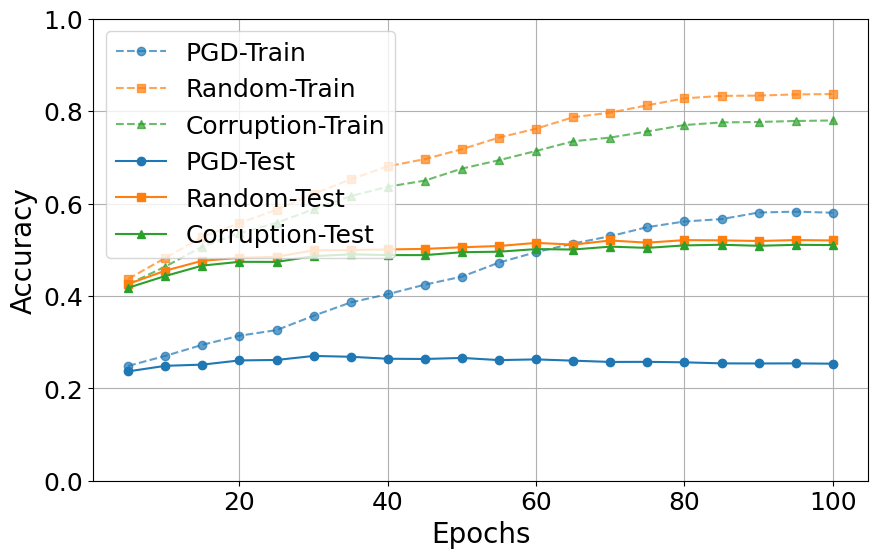

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Epochs', ylabel='Accuracy'>)

In [82]:
plot_data(
    file_path="../../ckp/nppr_training/adv_training/cifar10/resnet18/trades10_beta12/resnet18_cifar10_trades_training_info.csv",
    
    y_columns=["trainS_pgd", "trainS_random_l", "trainS_corr", \
         "val_pgd","val_random_l", "val_corr",],
    legend_names=["PGD-Train", "Random-Train", "Corruption-Train", "PGD-Test", "Random-Test", "Corruption-Test"],
    title="",
    ylabel="Accuracy"
)

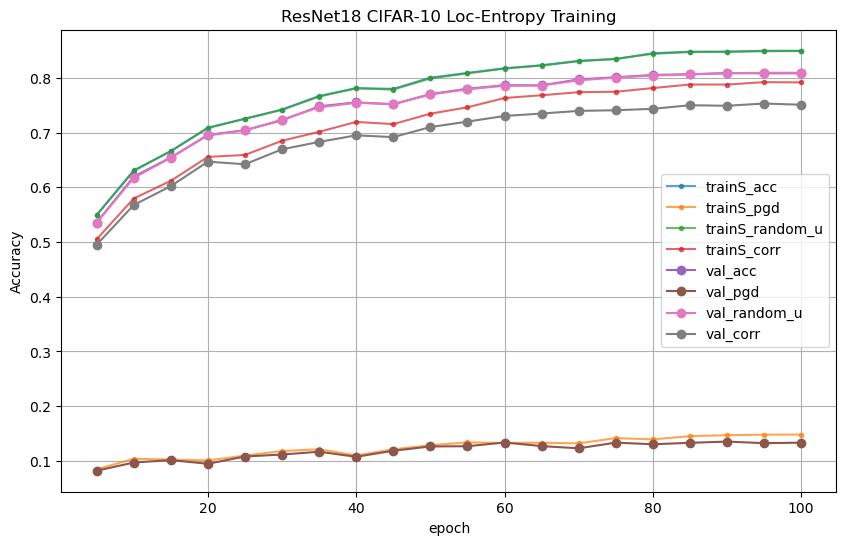

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'ResNet18 CIFAR-10 Loc-Entropy Training'}, xlabel='epoch', ylabel='Accuracy'>)

In [5]:
plot_data(
    file_path="../../ckp/nppr_training/pr_training/cifar10/resnet18/loc_entropy/loc_ent_eps10_L100_G0.05_N1_Aug_training_info.csv",
    
    y_columns=["trainS_acc", "trainS_pgd", "trainS_random_u", "trainS_corr", \
        "val_acc", "val_pgd", "val_random_u", "val_corr",],
    # legend_names=["Train Accuracy", "Validation Accuracy", "Validation PGD"],
    title="ResNet18 CIFAR-10 Loc-Entropy Training",
    ylabel="Accuracy"
)